<a href="https://colab.research.google.com/github/admixtureofus/somsom/blob/main/%EB%B2%A0%EC%9D%B4%EC%A7%95%EB%8C%80%EA%B8%B0%EC%A7%88%EB%8D%B0%EC%9D%B4%ED%84%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
import os
os.listdir('data')

# 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 설치한 폰트를 matplotlib에 등록
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 부호 깨짐도 같이 방지

In [ ]:
import glob
import pandas as pd

files = glob.glob('data/*.csv')
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(df.shape)   # (행 개수, 열 개수)
df          # 전체 dataframe 보기

(420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
420764,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
420765,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
420766,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


| 변수 | 설명 |
|---|---|
| No | 행 번호 (그냥 순번, 분석에 안 씀) |
| year / month / day / hour | 측정된 연/월/일/시간 |
대기오염물질 (6가지) — 단위: ㎍/㎥, CO만 mg/㎥
| 변수 | 설명 |
|---|---|
| PM2.5 | 초미세먼지 (지름 2.5μm 이하) — 폐 깊숙이 침투, 건강 영향 가장 큼 |
| PM10 | 미세먼지 (지름 10μm 이하, PM2.5 포함한 더 큰 범위) |
| SO2 | 이산화황 — 화석연료(석탄, 석유) 연소 시 발생, 산성비 원인 |
| NO2 | 이산화질소 — 자동차 배기가스, 공장 배출의 주범 |
| CO | 일산화탄소 — 불완전 연소 시 발생, 무색무취라 특히 위험 |
| O3 | 오존 — 자외선과 오염물질(NOx 등)이 반응해 생기는 2차 오염물질, 여름철 농도 높음 |
기상 변수 (6가지) — PM2.5에 영향을 줄 수 있는 날씨 조건
| 변수 | 설명 |
|---|---|
| TEMP | 기온 (섭씨) |
| PRES | 기압 (hPa) |
| DEWP | 이슬점 온도 — 공기 중 수증기량과 관련, 습도 지표 |
| RAIN | 강수량 (mm) — 비가 오면 미세먼지가 씻겨 내려가서 보통 PM2.5가 낮아짐 |
| wd | 풍향 (바람 방향, NNW/N/NW 같은 문자값) |
| WSPM | 풍속 (m/s) — 바람이 강하면 오염물질이 흩어져서 보통 PM2.5가 낮아짐 |
위치 정보
| 변수 | 설명 |
|---|---|
| station | 측정소 이름 (베이징 내 12개 지점 — Aotizhongxin, Dongsi, Guanyuan 등) |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [ ]:
# 각 컬럼마다 결측치(빈 값)가 몇 개인지 세기
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [ ]:
# 결측치 개수를 전체 행 개수로 나눠서 퍼센트(%)로 변환
# → 몇 %가 비어있는지 보기 편하게
df.isnull().sum() / len(df) * 100

,0
No,0.000000
year,0.000000
month,0.000000
day,0.000000
hour,0.000000
PM2.5,2.076916
PM10,1.532674
SO2,2.143937
NO2,2.879497
CO,4.919813


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

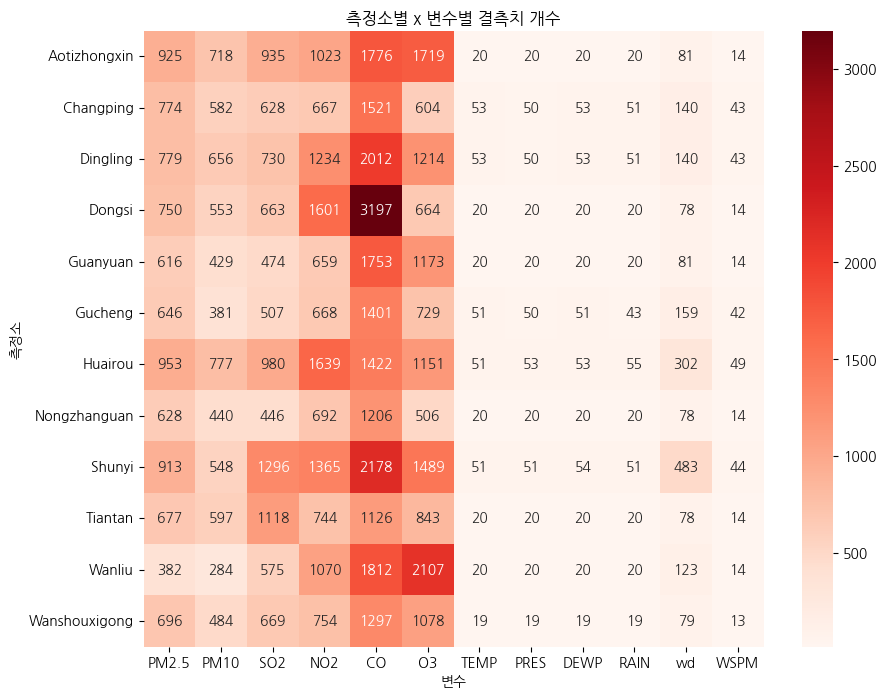

In [ ]:
cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','wd','WSPM']
 #측정소별 결측치
missing_by_station = df[cols].isnull().groupby(df['station']).sum()

plt.figure(figsize=(10,8))
sns.heatmap(missing_by_station, annot=True, fmt='d', cmap='Reds')
plt.title('측정소별 x 변수별 결측치 개수')
plt.xlabel('변수')
plt.ylabel('측정소')
plt.show()

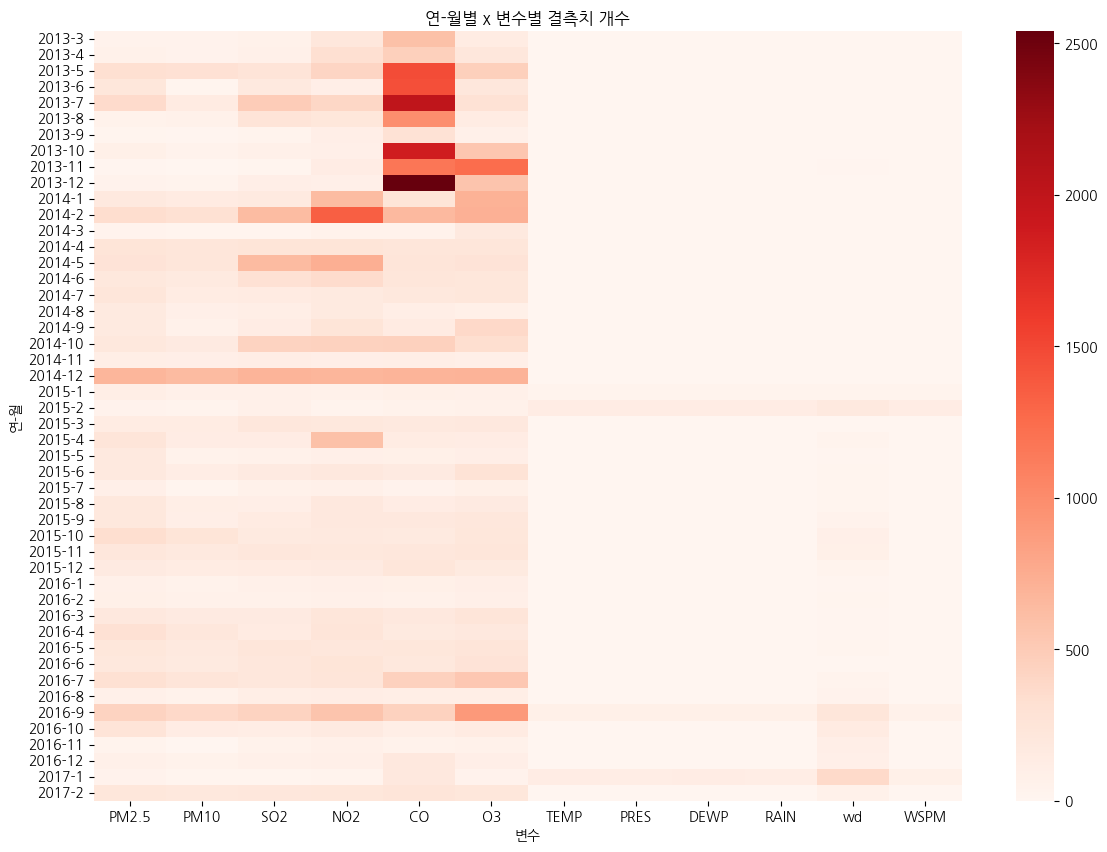

In [ ]:
#시기별 결측치
missing_by_time = df[cols].isnull().groupby([df['year'], df['month']]).sum()

plt.figure(figsize=(14,10))
sns.heatmap(missing_by_time, cmap='Reds')
plt.title('연-월별 x 변수별 결측치 개수')
plt.xlabel('변수')
plt.ylabel('연-월')
plt.show()

상황 요약:

CO 컬럼이 결측치가 제일 많음 (5%)
특히 **2013년(첫 해)**에 CO 결측이 몰려있음
특정 측정소(Dongsi, Shunyi 등)에도 좀 더 몰려있음
할 수 있는 조치 3가지

방법 A — 그냥 두기
선형보간으로 채우고 추가 작업 없이 그대로 진행
장점: 빠름, 데이터 손실 없음
단점: 2013년 CO 값들은 사실 "진짜 측정값"보다 "추정으로 채운 값" 비중이 높아서 신뢰도가 좀 떨어짐

방법 B — 2013년 초반 데이터를 아예 제외하고 분석
장점: 결측치가 많이 몰린 불안정한 구간을 아예 빼서, 남은 데이터의 신뢰도가 높아짐
단점: 데이터 4년 중 1년 가까이 버리는 셈이라 아까움

방법 C — CO만 따로 취급 (제일 정교한 방법)
나머지 5개 물질(PM2.5, PM10, SO2, NO2, O3)은 그대로 다 쓰고
CO 하나만 "2013년 데이터는 신뢰도가 낮으니 상관분석/회귀분석에서 2014년 이후 데이터만 사용" 이렇게 부분적으로 조정

In [ ]:
print(df.duplicated().sum())   # 완전히 똑같은 행이 몇 개인지

df = df.drop_duplicates()       # 있으면 제거
print(df.shape)                  # 제거 후 행 개수 확인

0
(420768, 18)


In [ ]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']
for col in pollutants:
    n = count_outliers_iqr(df[col])
    print(f'{col}: {n}개 ({n/len(df)*100:.1f}%)')

PM2.5: 19142개 (4.5%)
PM10: 14658개 (3.5%)
SO2: 35566개 (8.5%)
NO2: 7021개 (1.7%)
CO: 28054개 (6.7%)
O3: 16599개 (3.9%)



SO2, CO는 이상치 비율이 상대적으로 높게 나타났는데, 이는 난방철 등 특정 시기에 오염물질이 급증하는 대기질 데이터 특성상 자연스러운 현상으로, 오히려 물질 간 동조 패턴을 보여주는 신호로 해석

In [ ]:
# datetime 컬럼 먼저 만들기 (이게 없어서 에러 났던 것)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 2013년 CO 데이터만 필터링
co_2013 = df[df['year'] == 2013][['datetime', 'station', 'CO']].copy()

# 결측 여부를 True/False로 표시
co_2013['is_missing'] = co_2013['CO'].isnull()

# 측정소별로, 연속된 결측 구간의 길이를 계산
def get_max_consecutive_missing(group):
    groups = (~group['is_missing']).cumsum()
    consecutive_lengths = group[group['is_missing']].groupby(groups).size()
    return consecutive_lengths.max() if len(consecutive_lengths) > 0 else 0

max_gaps = co_2013.groupby('station')[['is_missing']].apply(get_max_consecutive_missing)
print(max_gaps)

station
Aotizhongxin      191
Changping         175
Dingling         1051
Dongsi           1517
Guanyuan          441
Gucheng           349
Huairou           211
Nongzhanguan      147
Shunyi            749
Tiantan            88
Wanliu            642
Wanshouxigong      50
dtype: int64



방법 C 선택 — CO만 따로 취급 (제일 정교한 방법)
나머지 5개 물질(PM2.5, PM10, SO2, NO2, O3)은 그대로 다 쓰고
CO 하나만 "2013년 데이터는 신뢰도가 낮으니 상관분석/회귀분석에서 2014년 이후 데이터만 사용" 이렇게 부분적으로 조정

In [ ]:
# 오염물질 6개 컬럼만 골라서 통계 요약(평균, 표준편차, 최소/최대값 등) 보기
# min 값이 음수면 측정 오류(이상치) 가능성 있음
df[['PM2.5','PM10','SO2','NO2','CO','O3']].describe()

,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000


In [ ]:
# 최댓값(상한선으로 추정되는 값)에 딱 걸린 데이터가 몇 개나 되는지 확인
print('PM2.5 == 999:', (df['PM2.5'] == 999).sum())
print('PM10 == 999:', (df['PM10'] == 999).sum())
print('CO == 10000:', (df['CO'] == 10000).sum())

PM2.5 == 999: 1
PM10 == 999: 3
CO == 10000: 56


In [ ]:
# year, month, day, hour 4개 컬럼을 하나의 datetime(날짜+시간) 컬럼으로 합치기
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 측정소별로, 시간 순서대로 정렬 (결측치 보간을 정확히 하려면 시간순 정렬이 필수)
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

In [ ]:
# 숫자형 컬럼: 측정소별로 선형보간
cols_to_fill = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

for col in cols_to_fill:
    df[col] = df.groupby('station')[col].transform(lambda x: x.interpolate(limit_direction='both'))

# 문자형 컬럼(wd, 풍향)은 보간이 안 되니, 측정소별로 바로 이전 시간대 값으로 채우기
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.ffill().bfill())

# 다 채워졌는지 다시 확인 (전부 0이면 성공)
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [ ]:
# 2013년 CO 데이터만 필터링
co_2013 = df[df['year'] == 2013][['datetime', 'station', 'CO']].copy()

# 결측 여부를 True/False로 표시
co_2013['is_missing'] = co_2013['CO'].isnull()

# 측정소별로, 연속된 결측 구간의 길이를 계산
def get_max_consecutive_missing(group):
    # 결측이 아닌 지점마다 그룹 번호를 새로 매겨서, 같은 그룹 = 연속 결측 구간
    groups = (~group['is_missing']).cumsum()
    consecutive_lengths = group[group['is_missing']].groupby(groups).size()
    return consecutive_lengths.max() if len(consecutive_lengths) > 0 else 0

max_gaps = co_2013.groupby('station').apply(get_max_consecutive_missing)
print(max_gaps)

station
Aotizhongxin     0
Changping        0
Dingling         0
Dongsi           0
Guanyuan         0
Gucheng          0
Huairou          0
Nongzhanguan     0
Shunyi           0
Tiantan          0
Wanliu           0
Wanshouxigong    0
dtype: int64


/tmp/ipykernel_930/2284564426.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_gaps = co_2013.groupby('station').apply(get_max_consecutive_missing)


In [ ]:
# 전처리 끝난 데이터를 cleaned_data.csv 파일로 저장
df.to_csv('cleaned_data.csv', index=False)